In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def initialize_grid(nx, T0, T_left, T_right):
    T = np.full(nx, T0, dtype=float)
    T[0] = T_left
    T[-1] = T_right
    return T

In [3]:
def timestep_ftcs(T, r, T_left, T_right):
    Tnew = T.copy()
    Tnew[1:-1] = T[1:-1] + r * (T[2:] - 2.0*T[1:-1] + T[:-2])
    Tnew[0] = T_left
    Tnew[-1] = T_right
    return Tnew

In [4]:
def compute_error(T, Tnew):
    return np.max(np.abs(Tnew - T))

In [5]:
def heat_conduction_ftcs(L=1.0, dx=0.01, dt=0.005, alpha=2.3e-5,
                         T0=30.0, T_left=0.0, T_right=100.0,
                         tol=1e-4, maxIt=2_000_000):
    nx = int(L/dx) + 1
    r = alpha * dt / (dx*dx)

    if r > 0.5:
        print(f"Warning: FTCS may be unstable, r = {r:.3f}")

    x = np.linspace(0, L, nx)
    T = initialize_grid(nx, T0, T_left, T_right)

    it = 0
    err = 1e9
    while it < maxIt:
        it += 1
        Tnew = timestep_ftcs(T, r, T_left, T_right)
        err = compute_error(T, Tnew)
        T = Tnew
        if err < tol:
            break

    print(f"Converged in {it} iterations, error={err:.3e}, r={r:.4f}")
    return x, T


Converged in 169177 iterations, error=1.000e-04, r=0.0011


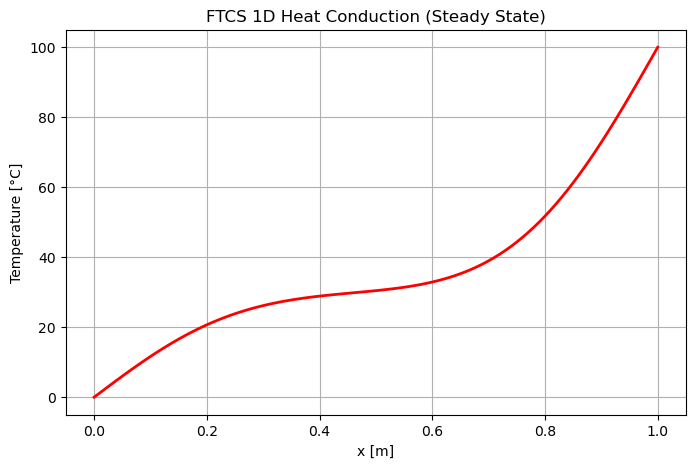

In [6]:
if __name__ == "__main__":
    x, T = heat_conduction_ftcs()

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(x, T, 'r-', linewidth=2)
    plt.xlabel("x [m]")
    plt.ylabel("Temperature [°C]")
    plt.title("FTCS 1D Heat Conduction (Steady State)")
    plt.grid(True)
    plt.show()